🚀 STOCK DATA RETRIEVAL AND PREDICTION ANALYSIS
📋 Configuration:
   Input CSV File: report/stock_forecast_ai_20250824.csv
   Output CSV File: report/stock_forecast_ai_20250824_actual_stock_data.csv

📂 Loading parameters from: report/stock_forecast_ai_20250824.csv
✅ Successfully loaded 20 tickers
📅 Date range: 2025-08-23 to 2025-08-29
📊 Date columns found: ['2025-08-23', '2025-08-24', '2025-08-25', '2025-08-26', '2025-08-27', '2025-08-28', '2025-08-29']
🎯 Tickers: AMZN, AZO, BALL, BBY, CHRW, COST, CSX, DAL, DG, DLTR...

🔄 FETCHING ACTUAL STOCK DATA
📈 Fetching actual data for AMZN (1/20)...
   ⚠️  Used nearest trading day 2025-08-22 for 2025-08-23
   ⚠️  Used nearest trading day 2025-08-22 for 2025-08-24
   ⚠️  Used nearest trading day 2025-08-22 for 2025-08-25
   ⚠️  Used nearest trading day 2025-08-22 for 2025-08-26
   ⚠️  Used nearest trading day 2025-08-22 for 2025-08-27
   ⚠️  Used nearest trading day 2025-08-22 for 2025-08-28
   ⚠️  Used nearest trading day 2025-08-22 for 2025-08-29

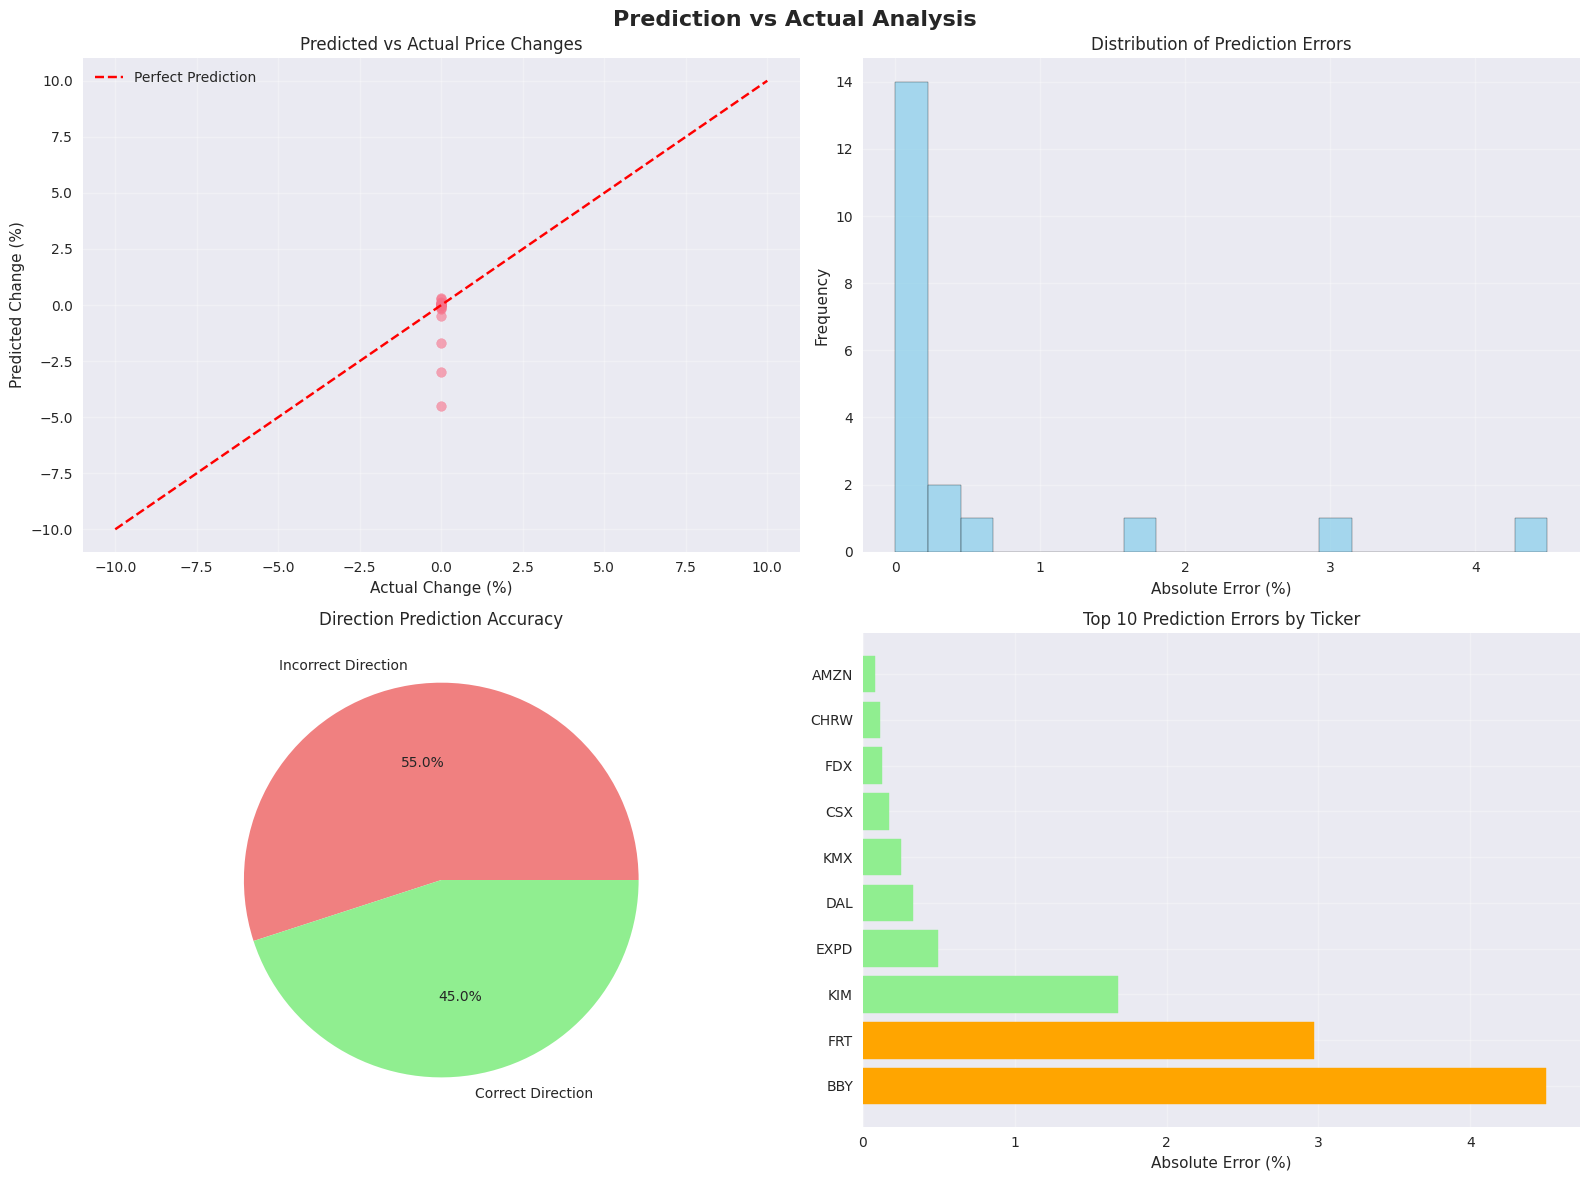


💾 Detailed comparison results saved to: prediction_analysis_results.csv

✅ Notebook execution completed!
💡 To use with your own CSV file, update the CSV_INPUT_FILE variable and re-run.


In [3]:
# Stock Data Retrieval with yfinance - CSV Input Version
# This notebook retrieves actual closing prices for tickers and dates specified in a CSV file

# Install required packages (uncomment if needed)
# !pip install yfinance pandas matplotlib seaborn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def load_csv_parameters(csv_file_path):
    """
    Load stock tickers and date range from CSV file.
    
    Parameters:
    -----------
    csv_file_path : str
        Path to the CSV file containing tickers and dates
    
    Returns:
    --------
    tuple
        (tickers_list, date_columns, start_date, end_date, original_df)
    """
    
    print(f"📂 Loading parameters from: {csv_file_path}")
    
    try:
        # Read the CSV file
        df = pd.read_csv(csv_file_path)
        
        # Extract tickers from first column
        tickers = df.iloc[:, 0].tolist()  # First column contains tickers
        
        # Extract date columns (assuming they are the next 7 columns after ticker)
        date_columns = []
        for col in df.columns[1:8]:  # Columns 1-7 (0-indexed)
            # Check if column name looks like a date
            try:
                # Try to parse the column name as a date
                pd.to_datetime(col)
                date_columns.append(col)
            except:
                # If it's not a date, skip it
                continue
        
        if not date_columns:
            raise ValueError("No valid date columns found in the CSV file")
        
        # Determine start and end dates
        start_date = min(date_columns)
        end_date = max(date_columns)
        
        print(f"✅ Successfully loaded {len(tickers)} tickers")
        print(f"📅 Date range: {start_date} to {end_date}")
        print(f"📊 Date columns found: {date_columns}")
        print(f"🎯 Tickers: {', '.join(tickers[:10])}" + ("..." if len(tickers) > 10 else ""))
        
        return tickers, date_columns, start_date, end_date, df
        
    except Exception as e:
        print(f"❌ Error loading CSV file: {str(e)}")
        return None, None, None, None, None

def get_stock_data_from_csv(csv_file_path, save_to_csv=True, csv_filename="actual_stock_data.csv"):
    """
    Retrieve actual closing prices for tickers and dates specified in CSV file.
    
    Parameters:
    -----------
    csv_file_path : str
        Path to the CSV file containing tickers and prediction dates
    save_to_csv : bool
        Whether to save the actual data to a CSV file
    csv_filename : str
        Name of the CSV file to save actual data to
    
    Returns:
    --------
    tuple
        (actual_data_df, original_predictions_df)
    """
    
    # Load parameters from CSV
    tickers, date_columns, start_date, end_date, original_df = load_csv_parameters(csv_file_path)
    
    if tickers is None:
        return None, None
    
    print("\n" + "="*60)
    print("🔄 FETCHING ACTUAL STOCK DATA")
    print("="*60)
    
    # Convert date strings to datetime objects for yfinance
    try:
        start_dt = pd.to_datetime(start_date)
        end_dt = pd.to_datetime(end_date)
        
        # Add one day to end date to ensure we get the end date data
        end_dt_fetch = end_dt + timedelta(days=1)
        
    except Exception as e:
        print(f"❌ Error parsing dates: {str(e)}")
        return None, None
    
    # Initialize results DataFrame with same structure as input
    actual_data = original_df.copy()
    failed_tickers = []
    success_count = 0
    
    for i, ticker in enumerate(tickers):
        try:
            print(f"📈 Fetching actual data for {ticker} ({i+1}/{len(tickers)})...")
            
            # Create yfinance ticker object
            stock = yf.Ticker(ticker)
            
            # Get historical data
            hist = stock.history(start=start_dt.strftime('%Y-%m-%d'), 
                               end=end_dt_fetch.strftime('%Y-%m-%d'))
            
            if hist.empty:
                print(f"❌ No data found for {ticker}")
                failed_tickers.append(ticker)
                continue
            
            # Update each date column with actual closing prices
            for date_col in date_columns:
                try:
                    date_dt = pd.to_datetime(date_col)
                    
                    # Remove timezone from historical data index for comparison
                    hist_index_no_tz = hist.index.tz_localize(None) if hist.index.tz is not None else hist.index
                    
                    # Create a copy of hist with timezone-naive index for easier comparison
                    hist_clean = hist.copy()
                    hist_clean.index = hist_index_no_tz
                    
                    # Convert target date to just date (no time) for comparison
                    target_date = date_dt.normalize()
                    
                    # Find exact match first
                    matching_dates = hist_clean.index[hist_clean.index.normalize() == target_date]
                    
                    if len(matching_dates) > 0:
                        # Use the first match if multiple exist
                        actual_price = hist_clean.loc[matching_dates[0], 'Close']
                        actual_data.loc[i, date_col] = round(actual_price, 2)
                    else:
                        # If exact date not found, find the nearest trading day
                        try:
                            nearest_idx = hist_clean.index.get_indexer([target_date], method='nearest')[0]
                            nearest_date = hist_clean.index[nearest_idx]
                            actual_price = hist_clean.loc[nearest_date, 'Close']
                            actual_data.loc[i, date_col] = round(actual_price, 2)
                            print(f"   ⚠️  Used nearest trading day {nearest_date.strftime('%Y-%m-%d')} for {date_col}")
                        except:
                            # Fallback: use the closest date by finding minimum difference
                            date_diffs = abs(hist_clean.index - target_date)
                            closest_idx = date_diffs.argmin()
                            closest_date = hist_clean.index[closest_idx]
                            actual_price = hist_clean.loc[closest_date, 'Close']
                            actual_data.loc[i, date_col] = round(actual_price, 2)
                            print(f"   ⚠️  Used closest available day {closest_date.strftime('%Y-%m-%d')} for {date_col}")
                        
                except Exception as date_error:
                    print(f"   ❌ Error processing date {date_col} for {ticker}: {str(date_error)}")
                    failed_tickers.append(f"{ticker}({date_col})")
            
            # Calculate actual 7-day change if we have start and end prices
            if len(date_columns) >= 2:
                start_price = actual_data.loc[i, date_columns[0]]
                end_price = actual_data.loc[i, date_columns[-1]]
                
                if pd.notna(start_price) and pd.notna(end_price):
                    actual_change = end_price - start_price
                    actual_change_pct = (actual_change / start_price) * 100
                    
                    # Update the change columns if they exist
                    if '7_Day_Change' in actual_data.columns:
                        actual_data.loc[i, '7_Day_Change'] = round(actual_change, 2)
                    if '7_Day_Change_Pct' in actual_data.columns:
                        actual_data.loc[i, '7_Day_Change_Pct'] = round(actual_change_pct, 2)
            
            success_count += 1
            print(f"✅ Successfully retrieved data for {ticker}")
            
        except Exception as e:
            print(f"❌ Error fetching data for {ticker}: {str(e)}")
            failed_tickers.append(ticker)
    
    print("\n" + "-"*50)
    print(f"📊 Results Summary:")
    print(f"   ✅ Successfully retrieved: {success_count}/{len(tickers)} tickers")
    print(f"   ❌ Failed: {len(failed_tickers)} tickers/dates")
    
    if failed_tickers:
        print(f"   Failed items: {', '.join(failed_tickers[:10])}" + ("..." if len(failed_tickers) > 10 else ""))
    
    # Save actual data to CSV if requested
    if save_to_csv and actual_data is not None:
        actual_data.to_csv(csv_filename, index=False)
        print(f"💾 Actual stock data saved to: {csv_filename}")
    
    return actual_data, original_df

def compare_predictions_vs_actual(predictions_df, actual_df):
    """
    Compare predicted vs actual stock prices.
    
    Parameters:
    -----------
    predictions_df : pandas.DataFrame
        DataFrame with predicted prices
    actual_df : pandas.DataFrame
        DataFrame with actual prices
    """
    
    if predictions_df is None or actual_df is None:
        print("❌ Cannot compare - missing data")
        return
    
    print("\n" + "="*60)
    print("📊 PREDICTION vs ACTUAL ANALYSIS")
    print("="*60)
    
    # Get date columns (excluding ticker and change columns)
    date_columns = [col for col in predictions_df.columns[1:8] if col not in ['7_Day_Change', '7_Day_Change_Pct']]
    
    if len(date_columns) < 2:
        print("❌ Need at least 2 date columns for comparison")
        return
    
    # Calculate prediction accuracy metrics
    results = []
    
    for i, ticker in enumerate(predictions_df['ticker']):
        try:
            # Get predicted and actual start/end prices
            pred_start = float(predictions_df.iloc[i][date_columns[0]])
            pred_end = float(predictions_df.iloc[i][date_columns[-1]])
            actual_start = float(actual_df.iloc[i][date_columns[0]])
            actual_end = float(actual_df.iloc[i][date_columns[-1]])
            
            # Calculate changes
            pred_change_pct = ((pred_end - pred_start) / pred_start) * 100
            actual_change_pct = ((actual_end - actual_start) / actual_start) * 100
            
            # Calculate errors
            absolute_error = abs(pred_change_pct - actual_change_pct)
            
            # Direction accuracy
            pred_direction = "Up" if pred_change_pct >= 0 else "Down"
            actual_direction = "Up" if actual_change_pct >= 0 else "Down"
            direction_correct = pred_direction == actual_direction
            
            results.append({
                'Ticker': ticker,
                'Pred_Start': pred_start,
                'Actual_Start': actual_start,
                'Pred_End': pred_end,
                'Actual_End': actual_end,
                'Pred_Change_%': pred_change_pct,
                'Actual_Change_%': actual_change_pct,
                'Abs_Error_%': absolute_error,
                'Direction_Correct': direction_correct,
                'Start_Price_Error_%': abs((actual_start - pred_start) / pred_start * 100),
                'End_Price_Error_%': abs((actual_end - pred_end) / pred_end * 100)
            })
            
        except Exception as e:
            print(f"❌ Error processing {ticker}: {str(e)}")
            continue
    
    # Convert to DataFrame for analysis
    results_df = pd.DataFrame(results)
    
    if results_df.empty:
        print("❌ No valid comparisons could be made")
        return results_df
    
    # Calculate summary statistics
    mean_abs_error = results_df['Abs_Error_%'].mean()
    rmse = np.sqrt((results_df['Abs_Error_%'] ** 2).mean())
    direction_accuracy = results_df['Direction_Correct'].mean() * 100
    mean_start_error = results_df['Start_Price_Error_%'].mean()
    mean_end_error = results_df['End_Price_Error_%'].mean()
    
    print(f"\n📈 ACCURACY METRICS:")
    print("-" * 30)
    print(f"Mean Absolute Error (Change %):     {mean_abs_error:.2f}%")
    print(f"Root Mean Squared Error:            {rmse:.2f}%")
    print(f"Direction Accuracy:                 {direction_accuracy:.1f}%")
    print(f"Mean Start Price Error:             {mean_start_error:.2f}%")
    print(f"Mean End Price Error:               {mean_end_error:.2f}%")
    print(f"Stocks Analyzed:                    {len(results_df)}")
    
    # Display top 10 best and worst predictions
    print(f"\n🏆 TOP 10 BEST PREDICTIONS (Lowest Error):")
    print("-" * 50)
    best_predictions = results_df.nsmallest(10, 'Abs_Error_%')[['Ticker', 'Pred_Change_%', 'Actual_Change_%', 'Abs_Error_%']]
    print(best_predictions.round(2))
    
    print(f"\n💥 TOP 10 WORST PREDICTIONS (Highest Error):")
    print("-" * 50)
    worst_predictions = results_df.nlargest(10, 'Abs_Error_%')[['Ticker', 'Pred_Change_%', 'Actual_Change_%', 'Abs_Error_%']]
    print(worst_predictions.round(2))
    
    return results_df

def plot_prediction_analysis(results_df, predictions_df, actual_df):
    """
    Create visualizations comparing predictions vs actual data.
    """
    
    if results_df is None or results_df.empty:
        print("❌ No data to plot")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Prediction vs Actual Analysis', fontsize=16, fontweight='bold')
    
    # 1. Predicted vs Actual Change scatter plot
    ax1 = axes[0, 0]
    ax1.scatter(results_df['Actual_Change_%'], results_df['Pred_Change_%'], alpha=0.6)
    ax1.plot([-10, 10], [-10, 10], 'r--', label='Perfect Prediction')
    ax1.set_xlabel('Actual Change (%)')
    ax1.set_ylabel('Predicted Change (%)')
    ax1.set_title('Predicted vs Actual Price Changes')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Error distribution
    ax2 = axes[0, 1]
    ax2.hist(results_df['Abs_Error_%'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax2.set_xlabel('Absolute Error (%)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Prediction Errors')
    ax2.grid(True, alpha=0.3)
    
    # 3. Direction accuracy
    ax3 = axes[1, 0]
    direction_counts = results_df['Direction_Correct'].value_counts()
    colors = ['lightcoral', 'lightgreen']
    labels = ['Incorrect Direction', 'Correct Direction']
    ax3.pie(direction_counts.values, labels=labels, colors=colors, autopct='%1.1f%%')
    ax3.set_title('Direction Prediction Accuracy')
    
    # 4. Top 10 errors by ticker
    ax4 = axes[1, 1]
    top_errors = results_df.nlargest(10, 'Abs_Error_%')
    bars = ax4.barh(range(len(top_errors)), top_errors['Abs_Error_%'])
    ax4.set_yticks(range(len(top_errors)))
    ax4.set_yticklabels(top_errors['Ticker'])
    ax4.set_xlabel('Absolute Error (%)')
    ax4.set_title('Top 10 Prediction Errors by Ticker')
    ax4.grid(True, alpha=0.3)
    
    # Color bars based on error magnitude
    for i, bar in enumerate(bars):
        error = top_errors.iloc[i]['Abs_Error_%']
        if error < 2:
            bar.set_color('lightgreen')
        elif error < 5:
            bar.set_color('orange')
        else:
            bar.set_color('lightcoral')
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# MAIN EXECUTION SECTION
# =============================================================================

print("🚀 STOCK DATA RETRIEVAL AND PREDICTION ANALYSIS")
print("=" * 60)

# INPUT PARAMETERS - MODIFY THESE AS NEEDED
# =============================================================================

file_in_root = "report/stock_forecast_ai_20250824"

# Path to your CSV file with predictions
CSV_INPUT_FILE = file_in_root + ".csv"  # Change this to your file path

# Output filename for actual data
ACTUAL_DATA_CSV = file_in_root + "_actual_stock_data.csv"

# =============================================================================

print(f"📋 Configuration:")
print(f"   Input CSV File: {CSV_INPUT_FILE}")
print(f"   Output CSV File: {ACTUAL_DATA_CSV}")

# Execute the data retrieval and analysis
print(f"\n{'='*60}")

try:
    # Step 1: Get actual stock data based on CSV parameters
    actual_data, prediction_data = get_stock_data_from_csv(
        csv_file_path=CSV_INPUT_FILE,
        save_to_csv=True,
        csv_filename=ACTUAL_DATA_CSV
    )
    
    if actual_data is not None and prediction_data is not None:
        
        # Step 2: Display data preview
        print(f"\n📊 ACTUAL DATA PREVIEW:")
        print("-" * 30)
        print("First 5 rows of actual data:")
        print(actual_data.head())
        
        print(f"\n📈 ORIGINAL PREDICTIONS PREVIEW:")
        print("-" * 30)
        print("First 5 rows of predictions:")
        print(prediction_data.head())
        
        # Step 3: Perform comparison analysis
        comparison_results = compare_predictions_vs_actual(prediction_data, actual_data)
        
        # Step 4: Create visualizations
        if comparison_results is not None and not comparison_results.empty:
            plot_prediction_analysis(comparison_results, prediction_data, actual_data)
            
            # Save comparison results
            comparison_results.to_csv(file_in_root + "_prediction_analysis_results.csv", index=False)
            print(f"\n💾 Detailed comparison results saved to: prediction_analysis_results.csv")
        
    else:
        print("❌ Failed to retrieve stock data. Please check your CSV file and try again.")

except FileNotFoundError:
    print(f"❌ Error: Could not find the file '{CSV_INPUT_FILE}'")
    print("Please make sure the file exists and the path is correct.")
    
    # Create a sample CSV file for demonstration
    sample_data = {
        'ticker': ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA'],
        '2024-01-02': [185.64, 140.93, 374.51, 151.94, 248.48],
        '2024-01-03': [184.25, 139.69, 373.85, 149.93, 242.64],
        '2024-01-04': [181.91, 141.11, 365.85, 148.31, 238.83],
        '2024-01-05': [181.18, 140.01, 361.30, 149.43, 234.52],
        '2024-01-08': [185.56, 143.01, 370.73, 153.75, 240.45],
        '2024-01-09': [185.14, 141.80, 368.84, 154.49, 238.68],
        '2024-01-10': [180.73, 139.52, 357.18, 149.96, 218.89],
        '7_Day_Change': [-4.91, -1.41, -17.33, -1.98, -29.59],
        '7_Day_Change_Pct': [-2.64, -1.00, -4.63, -1.30, -11.91]
    }
    
    sample_df = pd.DataFrame(sample_data)
    sample_df.to_csv("sample_stock_predictions.csv", index=False)
    print(f"\n💡 Created sample file 'sample_stock_predictions.csv' for demonstration.")
    print("You can use this file to test the notebook or replace it with your own data.")

except Exception as e:
    print(f"❌ Unexpected error: {str(e)}")

print("\n✅ Notebook execution completed!")
print("💡 To use with your own CSV file, update the CSV_INPUT_FILE variable and re-run.")